# GP1 preprocessing

This public notebook was migrated from the audited read-only research source. 
Configure paths in `config.yaml` before execution. Time is metadata and is never a model input.


In [ ]:
from pathlib import Path
import yaml

DATASET = 'GP1'
CWD = Path.cwd().resolve()
EXPERIMENT_DIR = CWD if (CWD / "config.yaml").is_file() else CWD / "experiments" / DATASET
REPO_ROOT = EXPERIMENT_DIR.parents[1]
import sys
sys.path.append(str(REPO_ROOT / "src"))

CONFIG = yaml.safe_load(
    (EXPERIMENT_DIR / "config.yaml").read_text(encoding="utf-8")
)

def experiment_path(value):
    path = Path(value)
    return path if path.is_absolute() else (EXPERIMENT_DIR / path).resolve()

DATA_ROOT = experiment_path(CONFIG["data_root"])
RUN_ROOT = experiment_path(CONFIG["run_root"])
CHECKPOINT_ROOT = experiment_path(CONFIG["checkpoint_root"])
SCANVI_DIR = experiment_path(CONFIG["scanvi_dir"])
SCANVI_ADATA = SCANVI_DIR / "adata.h5ad"
LR_PAIRS = experiment_path(CONFIG["lr_pairs_path"])
DIFF_MAP = experiment_path(CONFIG["diff_map_path"]) if "diff_map_path" in CONFIG else None
DATA_ROOT.mkdir(parents=True, exist_ok=True)
RUN_ROOT.mkdir(parents=True, exist_ok=True)
CHECKPOINT_ROOT.mkdir(parents=True, exist_ok=True)


In [ ]:
from pathlib import Path
import scanpy as sc 
import numpy as np
import pandas as pd


def read_visium(sample_dir: Path):
    import scanpy as sc

    if hasattr(sc, "read_visium"):
        count_file = "filtered_feature_bc_matrix.h5" if (sample_dir / "filtered_feature_bc_matrix.h5").exists() else None
        if count_file is not None:
            adata = sc.read_visium(path=str(sample_dir), count_file=count_file, load_images=True)
        else:
            adata = sc.read_visium(path=str(sample_dir), load_images=True)
        return adata

    try:
        import squidpy as sq
    except Exception as e:
        raise ImportError("Neither scanpy.read_visium nor squidpy.read.visium is available.") from e

    count_file = "filtered_feature_bc_matrix.h5" if (sample_dir / "filtered_feature_bc_matrix.h5").exists() else None
    if count_file is not None:
        return sq.read.visium(path=str(sample_dir), counts_file=count_file)
    return sq.read.visium(path=str(sample_dir))


def add_metadata_from_csv(
    adata,
    metadata_csv: Path,
    barcode_col="Cell",
):
    meta = pd.read_csv(metadata_csv)

    if barcode_col not in meta.columns:
        raise ValueError(f"{metadata_csv} must contain column: {barcode_col}")

    meta = meta.copy()
    meta[barcode_col] = meta[barcode_col].astype(str)

    # ， barcode  join 
    if meta[barcode_col].duplicated().any():
        dup_n = int(meta[barcode_col].duplicated().sum())
        print(f"Warning: found {dup_n} duplicated barcodes in metadata; keep first occurrence.")
        meta = meta.drop_duplicates(subset=[barcode_col], keep="first")

    meta = meta.set_index(barcode_col)

    adata = adata.copy()
    adata.obs.index = adata.obs.index.astype(str)

    # ： adata  barcode  metadata
    adata.obs = adata.obs.join(meta, how="left")

    matched = int(adata.obs.index.isin(meta.index).sum())
    print(f"Matched metadata: {matched}/{adata.n_obs}")

    return adata


def run_visium_build_h5ad(
    sample_dir,
    processed_dir,
    metadata_csv=None,
    out_name=None,
    barcode_col="Cell",
):
    sample_dir = Path(sample_dir).resolve()
    processed_dir = Path(processed_dir).resolve()

    print(f"Reading Visium data from: {sample_dir}")
    adata = read_visium(sample_dir)
    print(adata)

    #  counts
    adata.layers["counts"] = adata.X.copy()
    adata.var_names_make_unique()

    if metadata_csv is not None:
        metadata_csv = Path(metadata_csv).resolve()
        if not metadata_csv.exists():
            raise FileNotFoundError(f"Metadata CSV not found: {metadata_csv}")

        print(f"Reading metadata from: {metadata_csv}")
        adata = add_metadata_from_csv(
            adata,
            metadata_csv=metadata_csv,
            barcode_col=barcode_col,
        )

    out_h5ad = None
    if out_name is not None:
        out_h5ad = processed_dir / out_name
        adata.write_h5ad(out_h5ad)
        print(f"Saved: {out_h5ad}")
    print("Done.")

    return adata, out_h5ad

In [ ]:
adata, _ = run_visium_build_h5ad(
    sample_dir=DATA_ROOT / "raw",
    metadata_csv=DATA_ROOT / "P1_cluster.csv",
    processed_dir=DATA_ROOT,
    out_name=None,
    barcode_col="Cell",
)


Reading Visium data from: <external-data>/GP1/GP1


/tmp/ipykernel_2853434/374074324.py:13: FutureWarning: Use `squidpy.read.visium` instead.
  adata = sc.read_visium(path=str(sample_dir), count_file=count_file, load_images=True)
<conda-env>/lib/python3.12/site-packages/anndata/_core/anndata.py:1793: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
<conda-env>/lib/python3.12/site-packages/anndata/_core/anndata.py:1793: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 2174 × 36601
    obs: 'in_tissue', 'array_row', 'array_col'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'
Reading metadata from: <external-data>/GP1/GP1/P1_cluster.csv
Matched metadata: 2174/2174
Done.


In [ ]:
adata


AnnData object with n_obs × n_vars = 2174 × 36601
    obs: 'in_tissue', 'array_row', 'array_col', 'cluster'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'
    layers: 'counts'

In [ ]:
adata.obs["cluster"] = adata.obs["cluster"].astype(str).astype("category")

<conda-env>/lib/python3.12/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
<conda-env>/lib/python3.12/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


spatial libraries: ['1-KZ1']


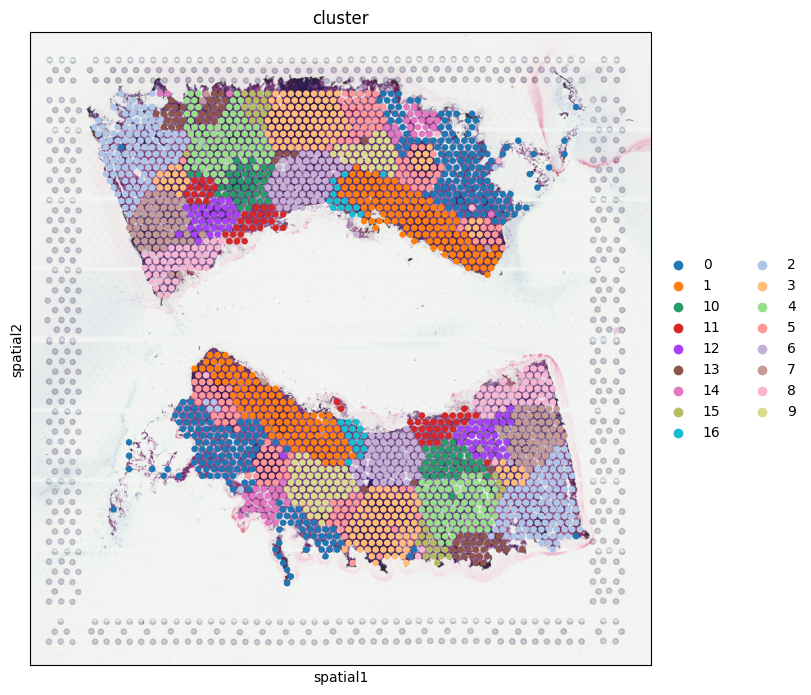

In [ ]:
import matplotlib.pyplot as plt
import squidpy as sq

#  library_id
print("spatial libraries:", list(adata.uns["spatial"].keys()))

lib = list(adata.uns["spatial"].keys())[0]

# +spot
sq.pl.spatial_scatter(
    adata,
    library_id=lib,
    color="cluster",   #  cluster，
    img=True,
    size=1.3,
    legend_loc="right margin",
    figsize=(8, 8),
)
plt.show()

In [ ]:
adata.obs["cluster"] = adata.obs["cluster"].astype(str)
adata.obs["cluster"] = adata.obs["cluster"].replace({"16": "1"})
adata.obs["cluster"] = adata.obs["cluster"].astype("category")

In [ ]:
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

In [ ]:
sc.tl.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)

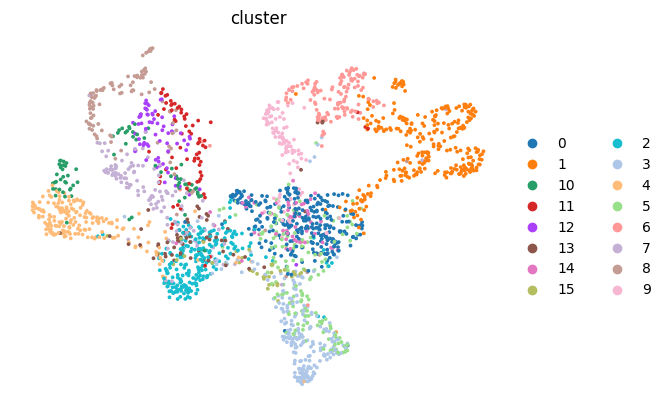

In [ ]:
sc.pl.umap(
    adata,
    color="cluster",
    size=30,
    frameon=False
)

In [ ]:
adata

AnnData object with n_obs × n_vars = 2174 × 36601
    obs: 'in_tissue', 'array_row', 'array_col', 'cluster'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial', 'cluster_colors', 'log1p', 'pca', 'neighbors', 'umap'
    obsm: 'spatial', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

In [ ]:
import scvi, os

In [ ]:
scvi.model.SCANVI.setup_anndata(
    adata,
    layer="counts",
    labels_key="cluster",
    unlabeled_category="Unknown",   
    batch_key=None
)
model = scvi.model.SCANVI(adata)
model.train()
model_dir = SCANVI_DIR

INFO     Training for 400 epochs.                                                                                  


Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA RTX PRO 6000 Blackwell Max-Q Workstation Edition') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
<conda-env>/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be 

Training:   0%|          | 0/400 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=400` reached.


In [ ]:
model_dir = SCANVI_DIR


In [ ]:
SCVI_LATENT_KEY = CONFIG.get("latent_key", "X_scanVI")
adata.obsm[SCVI_LATENT_KEY] = model.get_latent_representation()
adata.obsm[SCVI_LATENT_KEY].shape


(2174, 10)

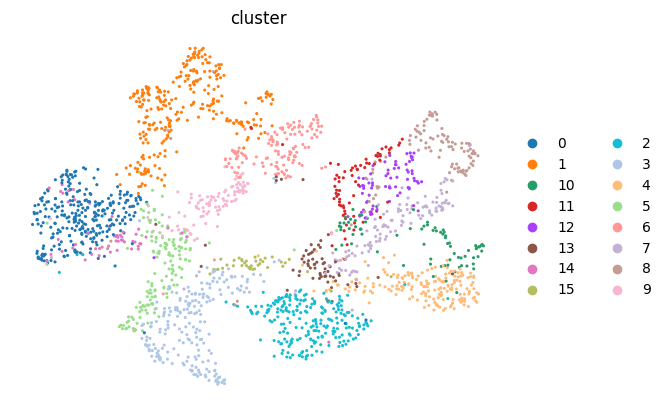

In [ ]:
sc.pp.neighbors(adata, use_rep=SCVI_LATENT_KEY)
sc.tl.umap(adata)
sc.pl.umap(adata, color=["cluster"],frameon=False,size = 20,)

In [ ]:
adata

AnnData object with n_obs × n_vars = 2174 × 36601
    obs: 'in_tissue', 'array_row', 'array_col', 'cluster', '_scvi_batch', '_scvi_labels'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial', 'cluster_colors', 'log1p', 'pca', 'neighbors', 'umap', '_scvi_uuid', '_scvi_manager_uuid'
    obsm: 'spatial', 'X_pca', 'X_umap', 'X_scanVI'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans


def split_cluster_state_upper_lower(
    adata,
    cluster_col="cluster",
    normal_clusters=("7", "8", "12"),
    cancer_clusters=("6", "9", "1"),
    merge_map={"16": "1"},
):
    if cluster_col not in adata.obs.columns:
        raise KeyError(f"adata.obs  {cluster_col}")

    if "spatial" not in adata.obsm:
        raise KeyError("adata.obsm  'spatial'")

    ad = adata.copy()

    # 1) cluster ， 16 -> 1
    ad.obs[cluster_col] = ad.obs[cluster_col].astype(str)
    if merge_map is not None:
        ad.obs[cluster_col] = ad.obs[cluster_col].replace(merge_map)

    # 2)  cluster
    keep_clusters = set(map(str, normal_clusters)) | set(map(str, cancer_clusters))
    ad = ad[ad.obs[cluster_col].isin(keep_clusters)].copy()

    # 3)  normal / cancer
    normal_clusters = set(map(str, normal_clusters))
    cancer_clusters = set(map(str, cancer_clusters))

    ad.obs["state"] = np.where(
        ad.obs[cluster_col].isin(normal_clusters),
        "normal",
        "cancer"
    )
    ad.obs["state"] = pd.Categorical(ad.obs["state"], categories=["normal", "cancer"])

    # 4)  spatial  y  upper / lower
    xy = np.asarray(ad.obsm["spatial"])
    y = xy[:, 1].reshape(-1, 1)

    km = KMeans(n_clusters=2, random_state=0, n_init=10)
    grp = km.fit_predict(y)

    means = {g: float(y[grp == g].mean()) for g in np.unique(grp)}
    upper_grp = min(means, key=means.get)   #  y 

    ad.obs["tissue_side"] = np.where(grp == upper_grp, "upper", "lower")
    ad.obs["tissue_side"] = pd.Categorical(ad.obs["tissue_side"], categories=["upper", "lower"])

    # 5)  adata
    adata_upper_normal = ad[(ad.obs["tissue_side"] == "upper") & (ad.obs["state"] == "normal")].copy()
    adata_lower_normal = ad[(ad.obs["tissue_side"] == "lower") & (ad.obs["state"] == "normal")].copy()
    adata_upper_cancer = ad[(ad.obs["tissue_side"] == "upper") & (ad.obs["state"] == "cancer")].copy()
    adata_lower_cancer = ad[(ad.obs["tissue_side"] == "lower") & (ad.obs["state"] == "cancer")].copy()

    # 
    ad.obs[cluster_col] = pd.Categorical(
        ad.obs[cluster_col],
        categories=sorted(ad.obs[cluster_col].astype(str).unique(), key=lambda x: int(x)),
        ordered=True
    )

    return {
        "adata_sub": ad,
        "adata_upper_normal": adata_upper_normal,
        "adata_lower_normal": adata_lower_normal,
        "adata_upper_cancer": adata_upper_cancer,
        "adata_lower_cancer": adata_lower_cancer,
    }

In [ ]:
res = split_cluster_state_upper_lower(
    adata,
    cluster_col="cluster",   #  cluster，
    normal_clusters=("7", "8", "12"),
    cancer_clusters=("6", "9", "1"),
    merge_map={"16": "1"},
)

adata_sub = res["adata_sub"]
adata_upper_normal = res["adata_upper_normal"]
adata_lower_normal = res["adata_lower_normal"]
adata_upper_cancer = res["adata_upper_cancer"]
adata_lower_cancer = res["adata_lower_cancer"]

print(adata_sub)
print("upper_normal :", adata_upper_normal.shape)
print("lower_normal :", adata_lower_normal.shape)
print("upper_cancer :", adata_upper_cancer.shape)
print("lower_cancer :", adata_lower_cancer.shape)

AnnData object with n_obs × n_vars = 812 × 36601
    obs: 'in_tissue', 'array_row', 'array_col', 'cluster', '_scvi_batch', '_scvi_labels', 'state', 'tissue_side'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial', 'cluster_colors', 'log1p', 'pca', 'neighbors', 'umap', '_scvi_uuid', '_scvi_manager_uuid'
    obsm: 'spatial', 'X_pca', 'X_umap', 'X_scanVI'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'
upper_normal : (151, 36601)
lower_normal : (151, 36601)
upper_cancer : (247, 36601)
lower_cancer : (263, 36601)


In [ ]:
adata_upper_normal = res["adata_upper_normal"]
adata_upper_cancer = res["adata_upper_cancer"]

/tmp/ipykernel_2853434/497386113.py:3: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_sub, color=["cluster", "state", "tissue_side"], spot_size=150)


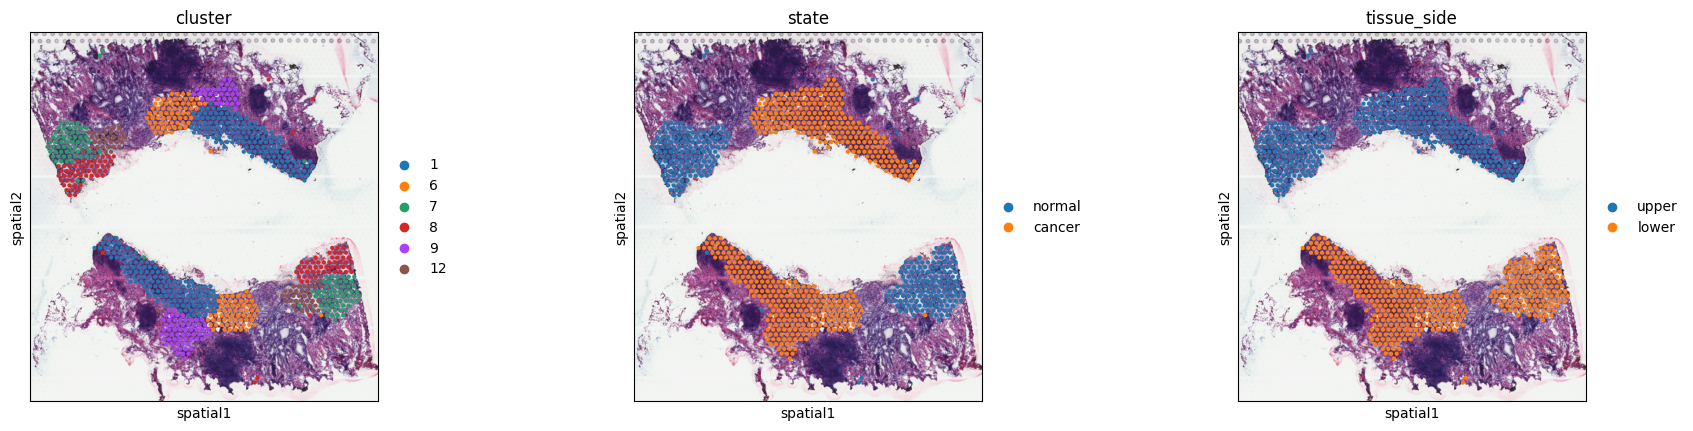

/tmp/ipykernel_2853434/497386113.py:4: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_upper_normal, color=["cluster"], spot_size=150)


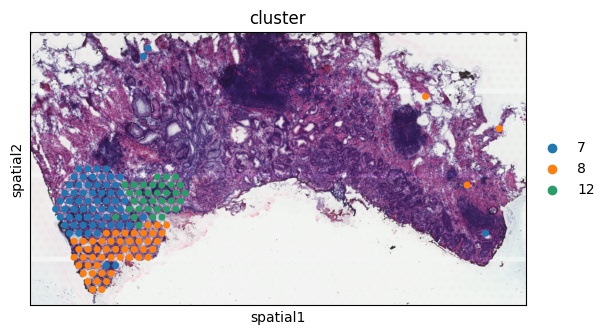

/tmp/ipykernel_2853434/497386113.py:5: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_upper_cancer, color=["cluster"], spot_size=150)


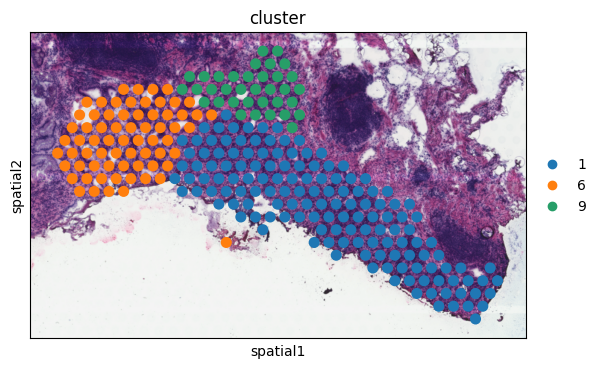

In [ ]:
import scanpy as sc

sc.pl.spatial(adata_sub, color=["cluster", "state", "tissue_side"], spot_size=150)
sc.pl.spatial(adata_upper_normal, color=["cluster"], spot_size=150)
sc.pl.spatial(adata_upper_cancer, color=["cluster"], spot_size=150)

In [ ]:
import numpy as np
from sklearn.neighbors import NearestNeighbors, radius_neighbors_graph
from scipy.sparse.csgraph import connected_components


def keep_largest_spatial_component(
    adata,
    spatial_key="spatial",
    radius=None,
    radius_scale=1.35,
    return_mask=False,
    verbose=True,
):
    """
    。
    radius ，。
    """
    if spatial_key not in adata.obsm:
        raise KeyError(f"adata.obsm  {spatial_key}")

    xy = np.asarray(adata.obsm[spatial_key], dtype=float)
    if xy.ndim != 2 or xy.shape[1] < 2:
        raise ValueError(f"adata.obsm['{spatial_key}']  n x 2")

    if adata.n_obs <= 1:
        return (adata.copy(), np.ones(adata.n_obs, dtype=bool)) if return_mask else adata.copy()

    # ：
    if radius is None:
        nn = NearestNeighbors(n_neighbors=2)
        nn.fit(xy)
        dists, _ = nn.kneighbors(xy)
        nn1 = dists[:, 1]
        base = float(np.median(nn1[np.isfinite(nn1)]))
        radius = radius_scale * base

    # ：
    G = radius_neighbors_graph(xy, radius=radius, mode="connectivity", include_self=False)
    n_comp, labels = connected_components(G, directed=False)

    comp_sizes = np.bincount(labels)
    largest_label = np.argmax(comp_sizes)
    keep_mask = (labels == largest_label)

    if verbose:
        print(f"radius = {radius:.3f}")
        print(f"n_components = {n_comp}")
        print(f"largest component size = {comp_sizes[largest_label]}/{adata.n_obs}")
        print(f"dropped = {(~keep_mask).sum()}")

    out = adata[keep_mask].copy()
    return (out, keep_mask) if return_mask else out

In [ ]:
adata_upper_normal_clean = keep_largest_spatial_component(adata_upper_normal)
adata_upper_cancer_clean = keep_largest_spatial_component(adata_upper_cancer)

radius = 268.650
n_components = 6
largest component size = 145/151
dropped = 6
radius = 268.650
n_components = 2
largest component size = 246/247
dropped = 1


/tmp/ipykernel_2853434/15844905.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_upper_normal_clean, color="cluster", spot_size=150, alpha_img=0.25)


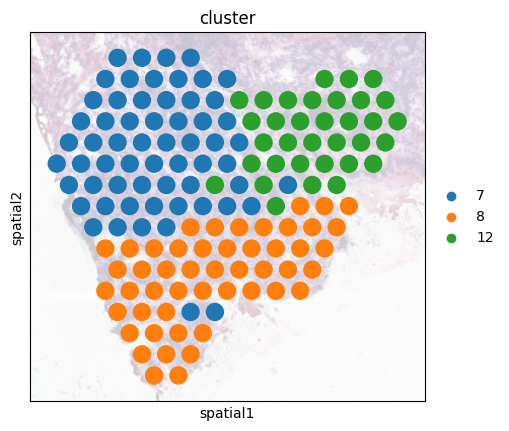

/tmp/ipykernel_2853434/15844905.py:2: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_upper_cancer_clean, color="cluster", spot_size=150, alpha_img=0.25)


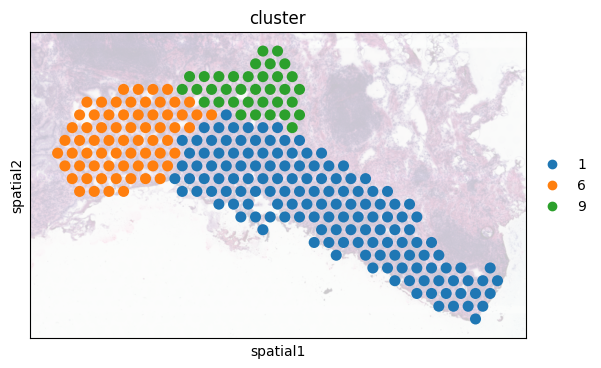

In [ ]:
sc.pl.spatial(adata_upper_normal_clean, color="cluster", spot_size=150, alpha_img=0.25)
sc.pl.spatial(adata_upper_cancer_clean, color="cluster", spot_size=150, alpha_img=0.25)

In [ ]:
import sys

from stvirtual.models import uot_alignment_trans as alt

In [ ]:
import anndata as ad

adata_upper_normal_clean = adata_upper_normal_clean.copy()
adata_upper_cancer_clean = adata_upper_cancer_clean.copy()

adata_upper_normal_clean.obs["status"] = "normal"
adata_upper_cancer_clean.obs["status"] = "cancer"

adata_upper_normal_clean.obs["status"] = adata_upper_normal_clean.obs["status"].astype("category")
adata_upper_cancer_clean.obs["status"] = adata_upper_cancer_clean.obs["status"].astype("category")

adata_upper_merged = ad.concat(
    {
        "normal": adata_upper_normal_clean,
        "cancer": adata_upper_cancer_clean,
    },
    join="outer",
    label="source",
    index_unique="-",
    merge="same",
)

adata_upper_merged.obs["status"] = adata_upper_merged.obs["status"].astype("category")

print(adata_upper_merged)
print(adata_upper_merged.obs["status"].value_counts())

AnnData object with n_obs × n_vars = 391 × 36601
    obs: 'in_tissue', 'array_row', 'array_col', 'cluster', '_scvi_batch', '_scvi_labels', 'state', 'tissue_side', 'status', 'source'
    var: 'gene_ids', 'feature_types', 'genome'
    obsm: 'spatial', 'X_pca', 'X_umap', 'X_scanVI'
    varm: 'PCs'
    layers: 'counts'
status
cancer    246
normal    145
Name: count, dtype: int64


In [ ]:
import importlib
importlib.reload(alt)

ad_src = adata_upper_merged[adata_upper_merged.obs["status"] == "normal"].copy()
ad_ref = adata_upper_merged[adata_upper_merged.obs["status"] == "cancer"].copy()

# --- spatial (2D) ---
X_src = np.asarray(ad_src.obsm["spatial"][:, :2], dtype=np.float64)
X_ref = np.asarray(ad_ref.obsm["spatial"][:, :2], dtype=np.float64)

# --- features: UMAP/PCA (must be comparable across slices) ---
F_src = np.asarray(ad_src.obsm["X_pca"], dtype=np.float64)
F_ref = np.asarray(ad_ref.obsm["X_pca"], dtype=np.float64)

# --- optional labels (clone) ---
ann_src = ad_src.obs["cluster"].astype(str).values
ann_ref = ad_ref.obs["cluster"].astype(str).values

# ===== normalize spatial to stabilize rigid fitting (recommended) =====
X_all = np.vstack([X_src, X_ref]).astype(np.float64)
mu = X_all.mean(axis=0, keepdims=True)
sd = X_all.std(axis=0, keepdims=True) + 1e-8

X_src_n = (X_src - mu) / sd
X_ref_n = (X_ref - mu) / sd

import numpy as np

def minmax01_joint(F_src, F_ref, eps=1e-8, q=None):
    """
    Joint min-max scaling to [0,1] per-dimension, using src+ref together.
    q=None -> exact min/max
    q=(0.01,0.99) -> robust quantile min/max (recommended if outliers)
    """
    F_src = np.asarray(F_src, np.float64)
    F_ref = np.asarray(F_ref, np.float64)
    F_all = np.vstack([F_src, F_ref])

    if q is None:
        fmin = F_all.min(axis=0, keepdims=True)
        fmax = F_all.max(axis=0, keepdims=True)
    else:
        lo, hi = q
        fmin = np.quantile(F_all, lo, axis=0, keepdims=True)
        fmax = np.quantile(F_all, hi, axis=0, keepdims=True)

    denom = np.maximum(fmax - fmin, eps)
    Fs = (F_src - fmin) / denom
    Fr = (F_ref - fmin) / denom

    # ，[0,1]，clip
    if q is not None:
        Fs = np.clip(Fs, 0.0, 1.0)
        Fr = np.clip(Fr, 0.0, 1.0)

    return Fs, Fr

Z_src = ad_src.obsm["X_pca"]
Z_ref = ad_ref.obsm["X_pca"]

# A： min/max
# F_src, F_ref = minmax01_joint(Z_src, Z_ref, q=None)

# B（）： min/max，
F_src, F_ref = minmax01_joint(Z_src, Z_ref, q=(0.01, 0.99))

# ===== register (run in normalized space, return normalized aligned coords) =====
X_aligned_n, info1 = alt.register_slice_to_ref_by_features(
    X_src_n, X_ref_n,
    F_src, F_ref,
    ann_src=None, ann_ref=None,
    k_feat=6,
    match_mode="soft",
    alpha_xy=1.0,
    beta_feat=1.0,
    tau=0.8,
    verbose=True,
)

# ===== unnormalize back to original spatial scale =====
X_aligned = X_aligned_n * sd + mu

xy_all = np.asarray(adata_upper_merged.obsm["spatial"][:, :2], dtype=float)

adata_upper_merged.obs["cx_aligned"] = xy_all[:, 0]
adata_upper_merged.obs["cy_aligned"] = xy_all[:, 1]

adata_upper_merged.obs.loc[ad_src.obs_names, "cx_aligned"] = X_aligned[:, 0]
adata_upper_merged.obs.loc[ad_src.obs_names, "cy_aligned"] = X_aligned[:, 1]

UOT init (feat):   0%|          | 0/18 [00:00<?, ?it/s, best=0.5499, reg=8.89, score=0.5499, th=1.85, trial=18]


[UOT init feat] BEST score=0.549902 reg=8.88871 theta=1.8516 t=[-0.2784056864355199, -0.9606378753221381]


ICP refine (feat): 100%|██████████| 40/40 [00:00<00:00, 62.76it/s, cls=1, med=0.4665, p90=0.9929, th=3.07, tx=-0.799, ty=-0.48] 


In [ ]:
def overlay_two_sets_by_ann(
    X_a, X_b,
    ann_a, ann_b,
    *,
    label_a="normal",
    label_b="cancer",
    title="Overlay by annotation",
    s_a=20, s_b=5,
    alpha_a=0.8, alpha_b=0.8,
    marker_a="o", marker_b="o",
    cmap_name="tab20",
    invert_y=True,
    axis_off=True,
    legend=True,
    dpi=100,
):
    """
    ， ann 
    X_a / X_b: (N,2)
    ann_a / ann_b: （ clone）
    """
    X_a = np.asarray(X_a, dtype=float)
    X_b = np.asarray(X_b, dtype=float)
    ann_a = np.asarray(ann_a).astype(str)
    ann_b = np.asarray(ann_b).astype(str)

    # （）
    all_cats = pd.Categorical(np.concatenate([ann_a, ann_b])).categories.tolist()
    cmap = plt.get_cmap(cmap_name)
    color_map = {c: cmap(i % cmap.N) for i, c in enumerate(all_cats)}

    # 
    X_all = np.vstack([X_a, X_b])
    xmin, ymin = X_all.min(axis=0)
    xmax, ymax = X_all.max(axis=0)
    w = max(xmax - xmin, 1e-6)
    h = max(ymax - ymin, 1e-6)
    padx, pady = 0.02 * w, 0.02 * h

    # 
    base = 6.5
    ratio = w / h
    figsize = (base * ratio, base) if ratio >= 1 else (base, base / ratio)

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

    #  B（） A（）
    for c in all_cats:
        mb = (ann_b == c)
        if np.any(mb):
            ax.scatter(
                X_b[mb, 0], X_b[mb, 1],
                s=s_b, c=[color_map[c]], alpha=alpha_b, linewidths=0,
                marker=marker_b, label=f"{c}"
            )

    for c in all_cats:
        ma = (ann_a == c)
        if np.any(ma):
            ax.scatter(
                X_a[ma, 0], X_a[ma, 1],
                s=s_a, c=[color_map[c]], alpha=alpha_a, linewidths=0,
                marker=marker_a
            )

    ax.set_title(title)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(xmin - padx, xmax + padx)
    ax.set_ylim(ymin - pady, ymax + pady)

    if invert_y:
        ax.invert_yaxis()
    if axis_off:
        ax.axis("off")

    # ： ann ，
    if legend:
        handles = [
            plt.Line2D([0], [0], marker='o', color='none',
                       markerfacecolor=color_map[c], markersize=5, label=str(c))
            for c in all_cats
        ]
        ax.legend(handles=handles, title="ann", bbox_to_anchor=(1.02, 1),
                  loc="upper left", borderaxespad=0.0, fontsize=8)

    # /
    ax.text(
        0.01, 0.01,
        f"front: {label_a}  |  back: {label_b}",
        transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7)
    )

    plt.tight_layout()
    plt.show()

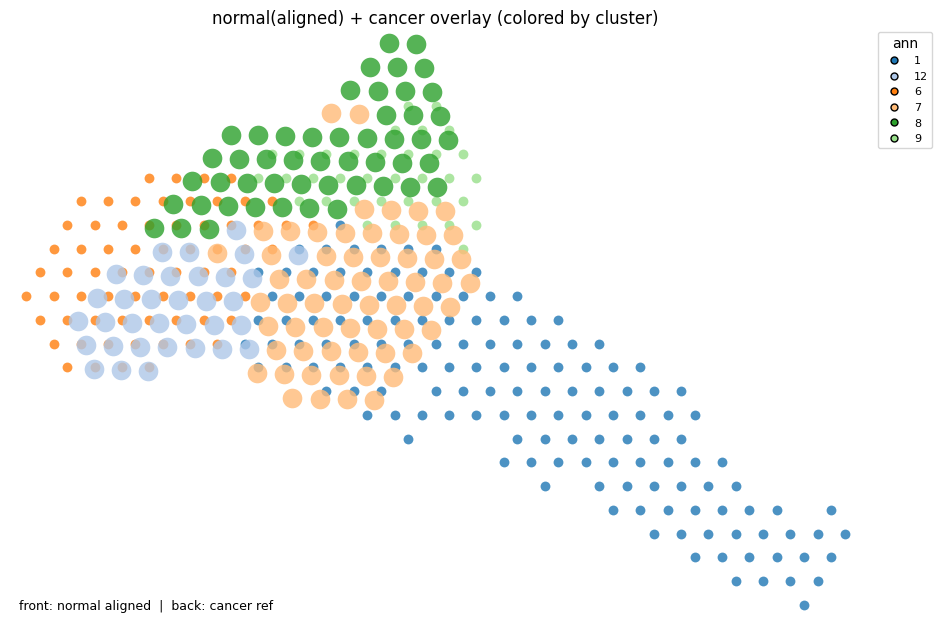

In [ ]:
X_src_aligned = X_aligned
overlay_two_sets_by_ann(
    X_a=X_src_aligned,   
    X_b=X_ref,     
    s_a=200,
    s_b=50,      
    ann_a=ann_src,       
    ann_b=ann_ref,       
    label_a="normal aligned",
    label_b="cancer ref",
    title="normal(aligned) + cancer overlay (colored by cluster)",
    invert_y=True,
    legend=True
)

In [ ]:
adata_upper_merged

AnnData object with n_obs × n_vars = 391 × 36601
    obs: 'in_tissue', 'array_row', 'array_col', 'cluster', '_scvi_batch', '_scvi_labels', 'state', 'tissue_side', 'status', 'source', 'cx_aligned', 'cy_aligned'
    var: 'gene_ids', 'feature_types', 'genome'
    obsm: 'spatial', 'X_pca', 'X_umap', 'X_scanVI'
    varm: 'PCs'
    layers: 'counts'

In [ ]:
model.save(model_dir, overwrite=True, save_anndata=True)
adata_upper_merged.write_h5ad(SCANVI_ADATA)
print(f"Saved model-ready AnnData: {SCANVI_ADATA}")


Saved model-ready AnnData: <repo>/experiments/GP1/artifacts/checkpoints/scanvi/adata.h5ad


In [ ]:
adata_lower_normal = res["adata_lower_normal"]
adata_lower_cancer = res["adata_lower_cancer"]

/tmp/ipykernel_2853434/3452420966.py:3: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_sub, color=["cluster", "state", "tissue_side"], spot_size=150)


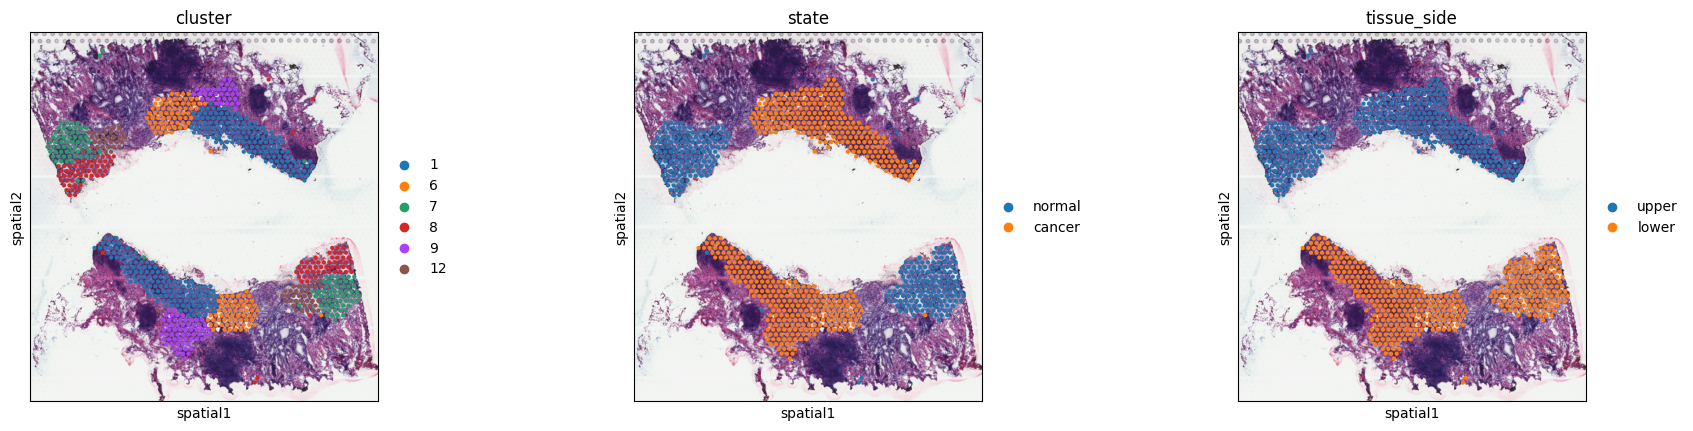

/tmp/ipykernel_2853434/3452420966.py:4: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_lower_normal, color=["cluster"], spot_size=150)


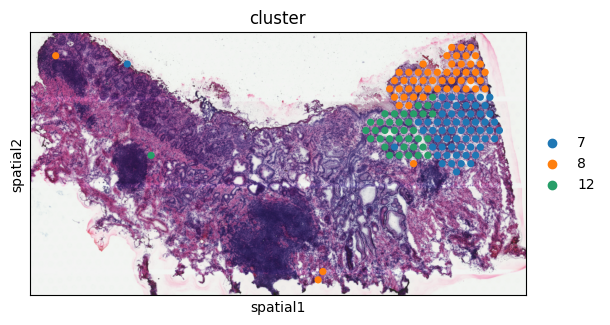

/tmp/ipykernel_2853434/3452420966.py:5: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_lower_cancer, color=["cluster"], spot_size=150)


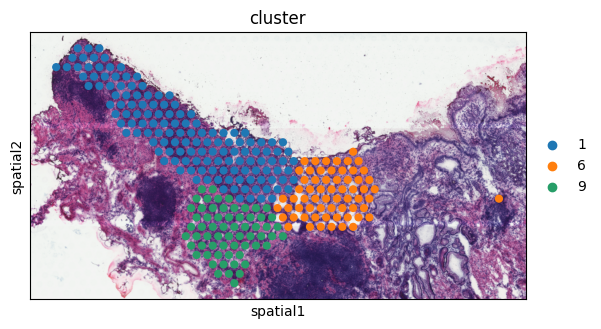

In [ ]:
import scanpy as sc

sc.pl.spatial(adata_sub, color=["cluster", "state", "tissue_side"], spot_size=150)
sc.pl.spatial(adata_lower_normal, color=["cluster"], spot_size=150)
sc.pl.spatial(adata_lower_cancer, color=["cluster"], spot_size=150)

In [ ]:
adata_lower_normal_clean = keep_largest_spatial_component(adata_lower_normal)
adata_lower_cancer_clean = keep_largest_spatial_component(adata_lower_cancer)

radius = 268.650
n_components = 5
largest component size = 146/151
dropped = 5
radius = 268.650
n_components = 2
largest component size = 262/263
dropped = 1


/tmp/ipykernel_2853434/3045503207.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_lower_normal_clean, color="cluster", spot_size=150, alpha_img=0.25)


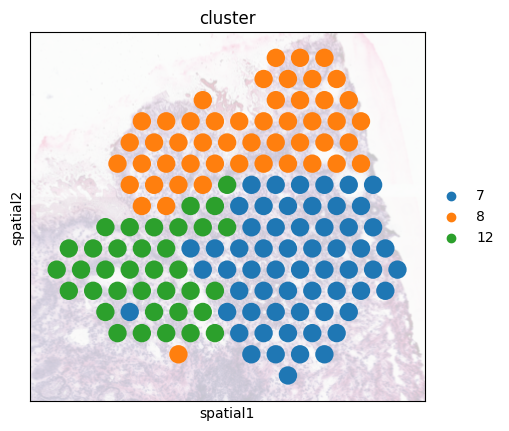

/tmp/ipykernel_2853434/3045503207.py:2: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_lower_cancer_clean, color="cluster", spot_size=150, alpha_img=0.25)


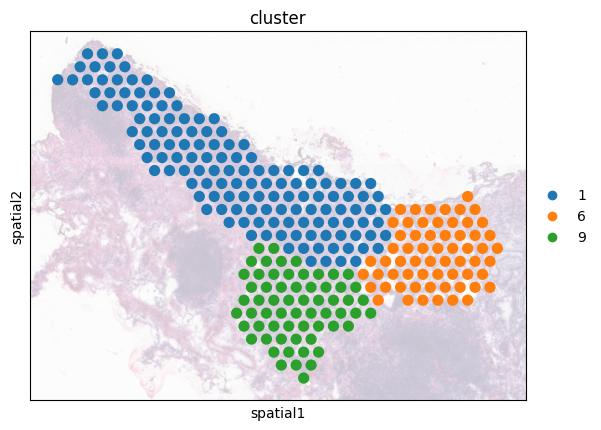

In [ ]:
sc.pl.spatial(adata_lower_normal_clean, color="cluster", spot_size=150, alpha_img=0.25)
sc.pl.spatial(adata_lower_cancer_clean, color="cluster", spot_size=150, alpha_img=0.25)

In [ ]:
adata_lower_normal_clean = adata_lower_normal_clean.copy()
adata_lower_cancer_clean = adata_lower_cancer_clean.copy()

adata_lower_normal_clean.obs["status"] = "normal"
adata_lower_cancer_clean.obs["status"] = "cancer"

adata_lower_normal_clean.obs["status"] = adata_lower_normal_clean.obs["status"].astype("category")
adata_lower_cancer_clean.obs["status"] = adata_lower_cancer_clean.obs["status"].astype("category")

adata_lower_merged = ad.concat(
    {
        "normal": adata_lower_normal_clean,
        "cancer": adata_lower_cancer_clean,
    },
    join="outer",
    label="source",
    index_unique="-",
    merge="same",
)

adata_lower_merged.obs["status"] = adata_lower_merged.obs["status"].astype("category")

print(adata_lower_merged)
print(adata_lower_merged.obs["status"].value_counts())

AnnData object with n_obs × n_vars = 408 × 36601
    obs: 'in_tissue', 'array_row', 'array_col', 'cluster', '_scvi_batch', '_scvi_labels', 'state', 'tissue_side', 'status', 'source'
    var: 'gene_ids', 'feature_types', 'genome'
    obsm: 'spatial', 'X_pca', 'X_umap', 'X_scanVI'
    varm: 'PCs'
    layers: 'counts'
status
cancer    262
normal    146
Name: count, dtype: int64


In [ ]:
print(adata_upper_merged)
print(adata_lower_merged)

AnnData object with n_obs × n_vars = 391 × 36601
    obs: 'in_tissue', 'array_row', 'array_col', 'cluster', '_scvi_batch', '_scvi_labels', 'state', 'tissue_side', 'status', 'source', 'cx_aligned', 'cy_aligned'
    var: 'gene_ids', 'feature_types', 'genome'
    obsm: 'spatial', 'X_pca', 'X_umap', 'X_scanVI'
    varm: 'PCs'
    layers: 'counts'
AnnData object with n_obs × n_vars = 408 × 36601
    obs: 'in_tissue', 'array_row', 'array_col', 'cluster', '_scvi_batch', '_scvi_labels', 'state', 'tissue_side', 'status', 'source'
    var: 'gene_ids', 'feature_types', 'genome'
    obsm: 'spatial', 'X_pca', 'X_umap', 'X_scanVI'
    varm: 'PCs'
    layers: 'counts'


In [ ]:
adata_lower2 = adata_lower_merged.copy()
adata_upper2 = adata_upper_merged.copy()

for x in [adata_lower2, adata_upper2]:
    if "pos" in x.obs.columns:
        x.obs = x.obs.loc[:, ~x.obs.columns.duplicated()].copy()
        x.obs.drop(columns=["pos"], errors="ignore", inplace=True)

adata_lower2.obs["pos"] = "lower"
adata_upper2.obs["pos"] = "upper"

adata_merge = ad.concat(
    [adata_lower2, adata_upper2],
    axis=0,
    join="outer",
    merge="same",
    index_unique=None,
)

adata_merge.obs["pos"] = pd.Categorical(
    adata_merge.obs["pos"].astype(str),
    categories=["lower", "upper"],
    ordered=True
)

adata_merge.obs = adata_merge.obs.loc[:, ~adata_merge.obs.columns.duplicated()].copy()

In [ ]:
adata_merge

AnnData object with n_obs × n_vars = 799 × 36601
    obs: 'in_tissue', 'array_row', 'array_col', 'cluster', '_scvi_batch', '_scvi_labels', 'state', 'tissue_side', 'status', 'source', 'pos', 'cx_aligned', 'cy_aligned'
    var: 'gene_ids', 'feature_types', 'genome'
    obsm: 'spatial', 'X_pca', 'X_umap', 'X_scanVI'
    varm: 'PCs'
    layers: 'counts'

In [ ]:
import numpy as np
import pandas as pd
from stvirtual.models import uot_alignment as al

ad_work = adata_merge.copy()
obs = ad_work.obs

# ----------  1D  ----------
def get_1d_col(df, col):
    x = df[col]
    if isinstance(x, pd.DataFrame):
        print(f"[warn] {col!r} ，")
        x = x.iloc[:, 0]
    return x

pos_col = get_1d_col(obs, "pos").astype(str)
cluster_col = get_1d_col(obs, "cluster").astype(str)

ref_sample = "upper"
all_samples = [x for x in pd.unique(pos_col) if pd.notna(x)]

print("All samples:", all_samples)
print("Reference sample:", ref_sample)

# ----------  spatial  ----------
if "spatial" not in ad_work.obsm:
    raise KeyError("ad_work.obsm  'spatial'")

XY_all = np.asarray(ad_work.obsm["spatial"], dtype=np.float32)
if XY_all.ndim != 2 or XY_all.shape[1] < 2:
    raise ValueError(f"obsm['spatial'] : {XY_all.shape}")

XY_all = XY_all[:, :2].copy()

if np.isnan(XY_all).any():
    raise ValueError("obsm['spatial']  NaN，")

xy_min = np.nanmin(XY_all, axis=0)
xy_max = np.nanmax(XY_all, axis=0)
xy_scale = (xy_max - xy_min).astype(np.float32)
xy_scale[xy_scale == 0] = 1.0

def xy_norm(X):
    X = np.asarray(X, dtype=np.float32)
    return (X - xy_min) / xy_scale

def xy_denorm(Xn):
    Xn = np.asarray(Xn, dtype=np.float32)
    return Xn * xy_scale + xy_min

# ----------  ----------
def rotate_about_center(X, deg=180):
    X = np.asarray(X, dtype=np.float32)
    theta = np.deg2rad(deg).astype(np.float32)
    c, s = np.cos(theta), np.sin(theta)
    R = np.array([[c, -s], [s, c]], dtype=np.float32)
    mu = X.mean(axis=0, keepdims=True)
    return (X - mu) @ R.T + mu

print("Normalize params:")
print("  xy_min =", xy_min)
print("  xy_max =", xy_max)

# ----------  ----------
for k in ["cx_aligned", "cy_aligned", "cx_aligned_norm", "cy_aligned_norm"]:
    if k not in ad_work.obs.columns:
        ad_work.obs[k] = np.nan

obs = ad_work.obs
cx_idx  = obs.columns.get_loc("cx_aligned")
cy_idx  = obs.columns.get_loc("cy_aligned")
cxn_idx = obs.columns.get_loc("cx_aligned_norm")
cyn_idx = obs.columns.get_loc("cy_aligned_norm")

def rows_of_pos(name):
    return np.flatnonzero(pos_col.to_numpy() == str(name))

def assign_coords(rows, X_orig, X_norm):
    X_orig = np.asarray(X_orig, dtype=np.float32)
    X_norm = np.asarray(X_norm, dtype=np.float32)
    if len(rows) != len(X_orig) or len(rows) != len(X_norm):
        raise ValueError(
            f": rows={len(rows)}, X_orig={len(X_orig)}, X_norm={len(X_norm)}"
        )
    obs.iloc[rows, cx_idx]  = X_orig[:, 0]
    obs.iloc[rows, cy_idx]  = X_orig[:, 1]
    obs.iloc[rows, cxn_idx] = X_norm[:, 0]
    obs.iloc[rows, cyn_idx] = X_norm[:, 1]

# ----------  ----------
rows_ref = rows_of_pos(ref_sample)
if len(rows_ref) == 0:
    raise ValueError(f" pos == {ref_sample!r} ")

X_ref_orig = XY_all[rows_ref]
X_ref_norm = xy_norm(X_ref_orig)
ann_ref = cluster_col.iloc[rows_ref].to_numpy()

assign_coords(rows_ref, X_ref_orig, X_ref_norm)

# ----------  ----------
for s in all_samples:
    if s == ref_sample:
        continue

    print(f"\n=== Registering {s} → {ref_sample} ===")

    rows_s = rows_of_pos(s)
    if len(rows_s) == 0:
        print(f"[skip] {s} ")
        continue

    X_src_orig = XY_all[rows_s]
    X_src_norm = xy_norm(X_src_orig)
    ann_src = cluster_col.iloc[rows_s].to_numpy()

    # lower  180 
    if s == "lower":
        X_src_norm_init = rotate_about_center(X_src_norm, deg=180)
        print("[init] lower  180°")
    else:
        X_src_norm_init = X_src_norm

    X_src_aligned, info2 = al.register_slice_to_ref_robust(
        X_src_norm_init,
        X_ref_norm,
        ann_src=ann_src,
        ann_ref=ann_ref,
        n_sub=3000,
        n_starts=3,
        reg=None,
        reg_m=1.0,
        icp_iter=80,
        icp_sub=10000,
        use_class_after=0,
        verbose=True,
    )

    print("final theta:", info2["refine"]["theta"])
    print("final t:", info2["refine"]["t"])

    X_src_warped_orig = xy_denorm(X_src_aligned)
    assign_coords(rows_s, X_src_warped_orig, X_src_aligned)

print("\nDone.")
print(" ad_work.obs:")
print(" cx_aligned, cy_aligned")
print(" cx_aligned_norm, cy_aligned_norm")

# ---------- ： 2D spatial ----------
ad_work.obsm["spatial_aligned_init"] = obs[["cx_aligned", "cy_aligned"]].to_numpy(dtype=np.float32)
ad_work.obsm["spatial_aligned_init_norm"] = obs[["cx_aligned_norm", "cy_aligned_norm"]].to_numpy(dtype=np.float32)

All samples: ['lower', 'upper']
Reference sample: upper
Normalize params:
  xy_min = [2565. 2623.]
  xy_max = [13806. 12663.]

=== Registering lower → upper ===
[init] lower  180°


UOT init:   0%|          | 0/9 [00:01<?, ?it/s, best=0.01315, reg=0.00838, score=0.02338, th=0.0979, trial=9]


[UOT init] BEST score=0.013153 reg=0.00209442 theta=0.0951 t=[-0.26708764805320667, -0.5148011330160699]


ICP refine: 100%|██████████| 80/80 [00:00<00:00, 106.42it/s, cls=1, med=0.006553, p90=0.01482, th=0.0949, tx=-0.269, ty=-0.522]


final theta: 0.094890270013824
final t: [-0.2688064364028552, -0.5220117760678453]

Done.
 ad_work.obs:
 cx_aligned, cy_aligned
 cx_aligned_norm, cy_aligned_norm


x_orig_col = array_col
y_orig_col = array_row
x_warp_col = cx_aligned
y_warp_col = cy_aligned
ann_col    = cluster
group_col  = pos


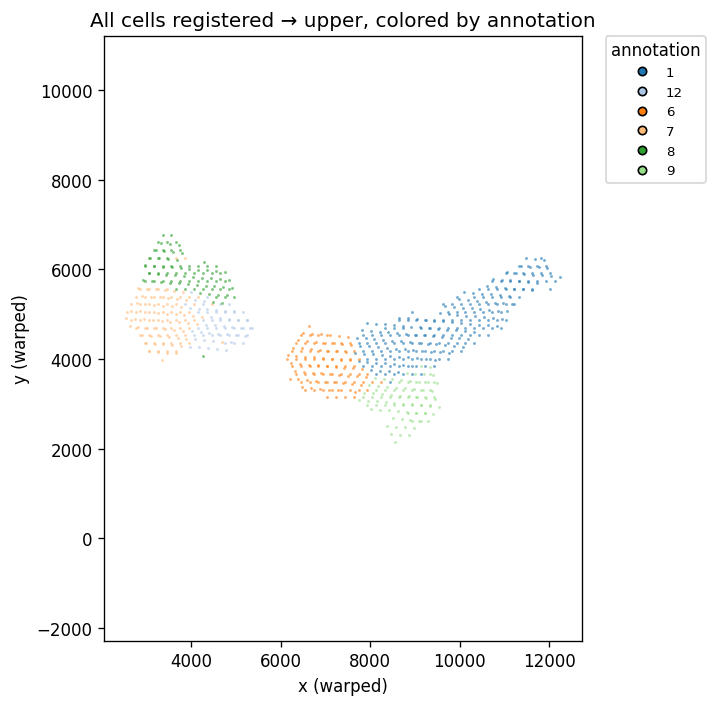

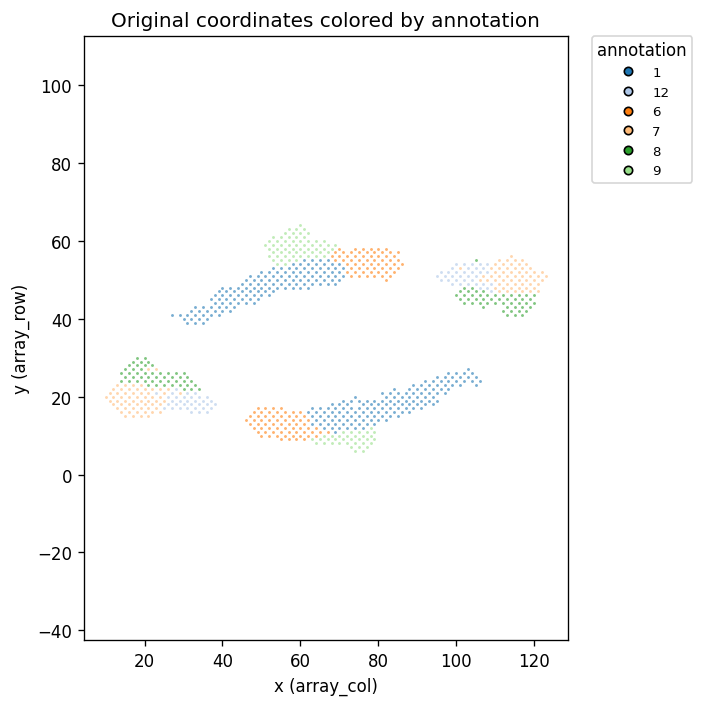

pos = lower
before bbox: (np.float64(96.0), np.float64(25.0))
after  bbox: (np.float64(9690.7705078125), np.float64(4442.914306640625))


In [ ]:
if "ad_work" in globals():
    ad_show = ad_work
elif "adata_merge" in globals():
    ad_show = adata_merge
else:
    raise ValueError(" ad_work  adata_merge")

obs = ad_show.obs

# =========================
#  1D ， DataFrame
# =========================
def get_1d_col(df, col):
    x = df[col]
    if isinstance(x, pd.DataFrame):
        print(f"[warn] {col!r} ，")
        x = x.iloc[:, 0]
    return x

def find_first_existing_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f": {candidates}")

# =========================
# 
# =========================
x_orig_col = find_first_existing_col(obs, ["coor_x", "array_col", "cx"])
y_orig_col = find_first_existing_col(obs, ["coor_y", "array_row", "cy"])
x_warp_col = find_first_existing_col(obs, ["cx_aligned"])
y_warp_col = find_first_existing_col(obs, ["cy_aligned"])
ann_col    = find_first_existing_col(obs, ["annotation", "cluster", "status"])
group_col  = find_first_existing_col(obs, ["pos", "sample"])

print("x_orig_col =", x_orig_col)
print("y_orig_col =", y_orig_col)
print("x_warp_col =", x_warp_col)
print("y_warp_col =", y_warp_col)
print("ann_col    =", ann_col)
print("group_col  =", group_col)

# =========================
# 
# =========================
ann_vals = get_1d_col(obs, ann_col).astype(str)
ann_cats = pd.Categorical(ann_vals).categories.tolist()

cmap = plt.get_cmap("tab20")
ann_color_map = {ann: cmap(i % 20) for i, ann in enumerate(ann_cats)}

# =========================
# 
# =========================
def plot_scatter_by_annotation(df, x_col, y_col, ann_col, title, xlabel, ylabel, s=3, alpha=0.6):
    df = df.copy()
    df = df[np.isfinite(df[x_col]) & np.isfinite(df[y_col])].copy()

    plt.figure(figsize=(6, 6), dpi=120)

    for ann in ann_cats:
        m = (df[ann_col].astype(str) == str(ann))
        if m.sum() == 0:
            continue
        plt.scatter(
            df.loc[m, x_col],
            df.loc[m, y_col],
            s=s,
            c=[ann_color_map[ann]],
            alpha=alpha,
            linewidths=0,
            label=str(ann)
        )

    plt.axis("equal")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)

    handles = [
        plt.Line2D(
            [0], [0],
            marker="o",
            color="none",
            markerfacecolor=ann_color_map[ann],
            markersize=5,
            label=str(ann)
        )
        for ann in ann_cats
    ]
    plt.legend(
        handles=handles,
        title=ann_col,
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
        borderaxespad=0.0,
        fontsize=8
    )
    plt.tight_layout()
    plt.show()

# =========================
# 1) 
# =========================
df_warp = pd.DataFrame({
    "x": pd.to_numeric(get_1d_col(obs, x_warp_col), errors="coerce").to_numpy(),
    "y": pd.to_numeric(get_1d_col(obs, y_warp_col), errors="coerce").to_numpy(),
    "annotation": get_1d_col(obs, ann_col).astype(str).to_numpy(),
    "group": get_1d_col(obs, group_col).astype(str).to_numpy(),
})

plot_scatter_by_annotation(
    df=df_warp,
    x_col="x",
    y_col="y",
    ann_col="annotation",
    title="All cells registered → upper, colored by annotation",
    xlabel="x (warped)",
    ylabel="y (warped)",
)

# =========================
# 2) 
# =========================
df_orig = pd.DataFrame({
    "x": pd.to_numeric(get_1d_col(obs, x_orig_col), errors="coerce").to_numpy(),
    "y": pd.to_numeric(get_1d_col(obs, y_orig_col), errors="coerce").to_numpy(),
    "annotation": get_1d_col(obs, ann_col).astype(str).to_numpy(),
    "group": get_1d_col(obs, group_col).astype(str).to_numpy(),
})

plot_scatter_by_annotation(
    df=df_orig,
    x_col="x",
    y_col="y",
    ann_col="annotation",
    title="Original coordinates colored by annotation",
    xlabel=f"x ({x_orig_col})",
    ylabel=f"y ({y_orig_col})",
)

# =========================
# 3)  bbox 
#  pos ， lower
# =========================
def bbox_size(X):
    X = np.asarray(X, dtype=float)
    X = X[np.isfinite(X).all(axis=1)]
    if len(X) == 0:
        return np.nan, np.nan
    w = X[:, 0].max() - X[:, 0].min()
    h = X[:, 1].max() - X[:, 1].min()
    return w, h

group_to_check = "lower"   #  "upper"

group_vals = get_1d_col(obs, group_col).astype(str)
mask_g = (group_vals == group_to_check).to_numpy()

X_before = np.column_stack([
    pd.to_numeric(get_1d_col(obs, x_orig_col), errors="coerce").to_numpy()[mask_g],
    pd.to_numeric(get_1d_col(obs, y_orig_col), errors="coerce").to_numpy()[mask_g],
])

X_after = np.column_stack([
    pd.to_numeric(get_1d_col(obs, x_warp_col), errors="coerce").to_numpy()[mask_g],
    pd.to_numeric(get_1d_col(obs, y_warp_col), errors="coerce").to_numpy()[mask_g],
])

print(f"{group_col} = {group_to_check}")
print("before bbox:", bbox_size(X_before))
print("after  bbox:", bbox_size(X_after))

In [ ]:
ad_work

AnnData object with n_obs × n_vars = 799 × 36601
    obs: 'in_tissue', 'array_row', 'array_col', 'cluster', '_scvi_batch', '_scvi_labels', 'state', 'tissue_side', 'status', 'source', 'pos', 'cx_aligned', 'cy_aligned', 'cx_aligned_norm', 'cy_aligned_norm'
    var: 'gene_ids', 'feature_types', 'genome'
    obsm: 'spatial', 'X_pca', 'X_umap', 'X_scanVI', 'spatial_aligned_init', 'spatial_aligned_init_norm'
    varm: 'PCs'
    layers: 'counts'

In [ ]:
adata_lower_clean = ad_show[ad_show.obs['pos']=='lower']
adata_lower_clean.obs['status'].value_counts()

status
cancer    262
normal    146
Name: count, dtype: int64

In [ ]:
adata_lower_clean

View of AnnData object with n_obs × n_vars = 408 × 36601
    obs: 'in_tissue', 'array_row', 'array_col', 'cluster', '_scvi_batch', '_scvi_labels', 'state', 'tissue_side', 'status', 'source', 'pos', 'cx_aligned', 'cy_aligned', 'cx_aligned_norm', 'cy_aligned_norm'
    var: 'gene_ids', 'feature_types', 'genome'
    obsm: 'spatial', 'X_pca', 'X_umap', 'X_scanVI', 'spatial_aligned_init', 'spatial_aligned_init_norm'
    varm: 'PCs'
    layers: 'counts'

In [ ]:
adata_lower_clean.obsm["spatial_aligned_init"] = adata_lower_clean.obs[["cx_aligned", "cy_aligned"]].to_numpy(dtype=float)
adata_lower_clean

/tmp/ipykernel_2853434/1800857053.py:1: ImplicitModificationWarning: Setting element `.obsm['spatial_aligned_init']` of view, initializing view as actual.
  adata_lower_clean.obsm["spatial_aligned_init"] = adata_lower_clean.obs[["cx_aligned", "cy_aligned"]].to_numpy(dtype=float)


AnnData object with n_obs × n_vars = 408 × 36601
    obs: 'in_tissue', 'array_row', 'array_col', 'cluster', '_scvi_batch', '_scvi_labels', 'state', 'tissue_side', 'status', 'source', 'pos', 'cx_aligned', 'cy_aligned', 'cx_aligned_norm', 'cy_aligned_norm'
    var: 'gene_ids', 'feature_types', 'genome'
    obsm: 'spatial', 'X_pca', 'X_umap', 'X_scanVI', 'spatial_aligned_init', 'spatial_aligned_init_norm'
    varm: 'PCs'
    layers: 'counts'

In [ ]:
adata_upper_clean = ad_show[ad_show.obs['pos']=='upper']
adata_upper_clean.obs['status'].value_counts()

status
cancer    246
normal    145
Name: count, dtype: int64

/tmp/ipykernel_2853434/1849075661.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_lower_clean, color=["cluster"], spot_size=150)


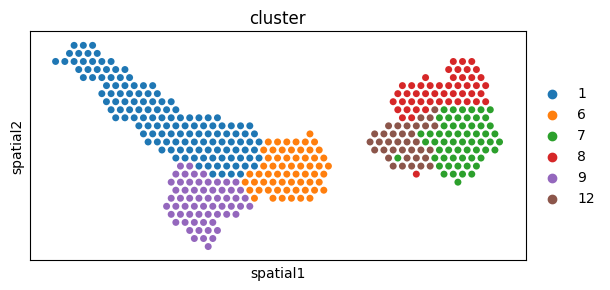

In [ ]:
sc.pl.spatial(adata_lower_clean, color=["cluster"], spot_size=150)

/tmp/ipykernel_2853434/3675273509.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_upper_clean, color=["cluster"], spot_size=150)
<conda-env>/lib/python3.12/site-packages/scanpy/plotting/_utils.py:482: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


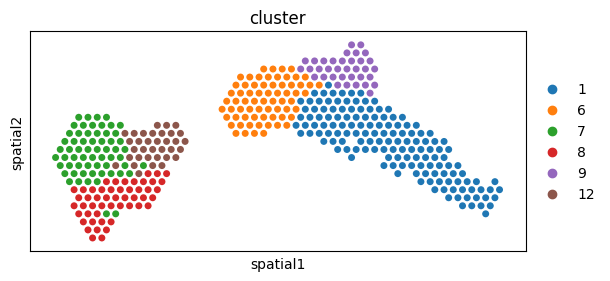

In [ ]:
sc.pl.spatial(adata_upper_clean, color=["cluster"], spot_size=150)

Done.
normal mapped: 146
cancer kept : 262


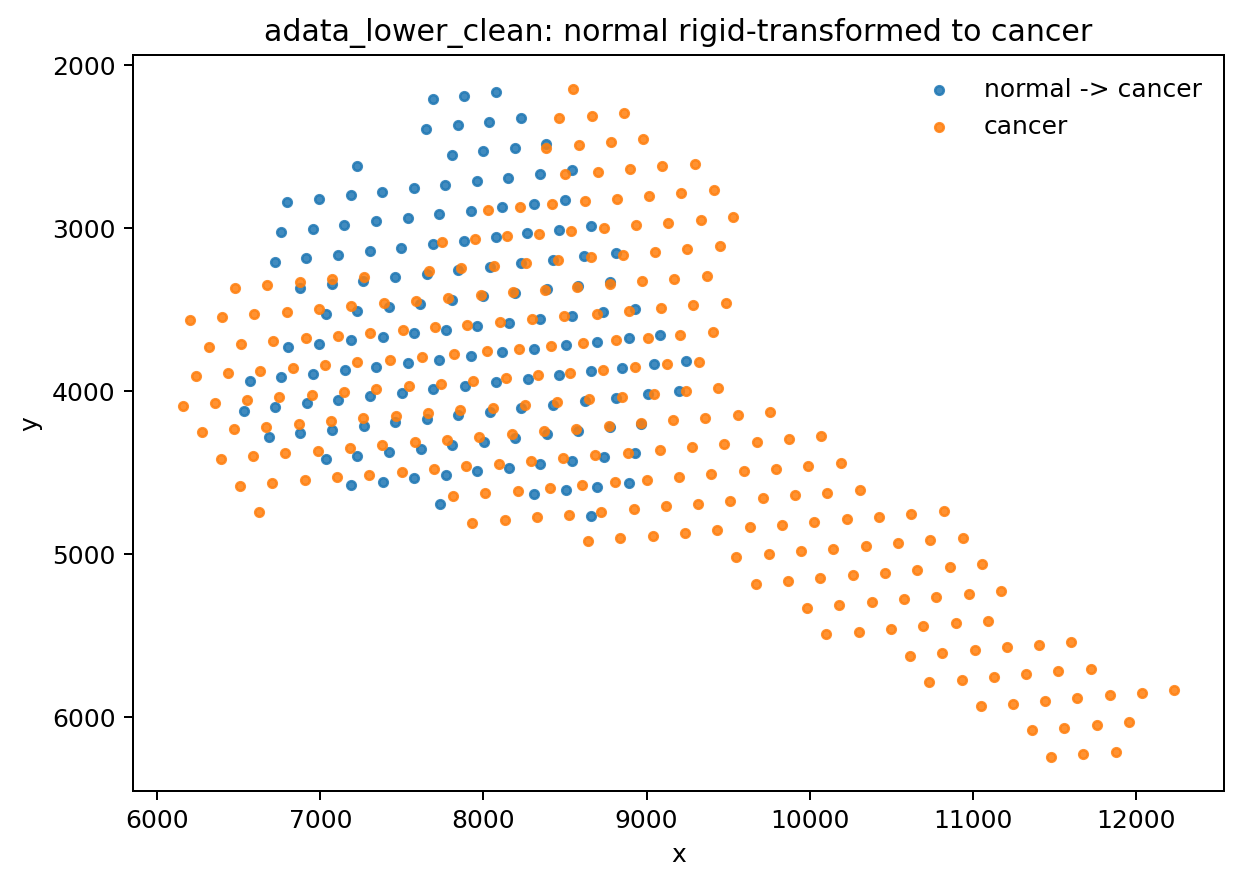

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 0)  info1 
#    info1  upper normal -> upper cancer 
# =========================================================
R1 = np.asarray(info1["R"], dtype=np.float64)                  # shape (2, 2)
t1 = np.asarray(info1["t"], dtype=np.float64).reshape(1, 2)   # shape (1, 2)

#  mu, sd  normal -> cancer 
# ：
# X_all = np.vstack([X_src, X_ref]).astype(np.float64)
# mu = X_all.mean(axis=0, keepdims=True)
# sd = X_all.std(axis=0, keepdims=True) + 1e-8

# =========================================================
# 1)  adata_lower_clean  upper 
# =========================================================
X_base = np.asarray(adata_lower_clean.obsm["spatial_aligned_init"][:, :2], dtype=np.float64)

status = adata_lower_clean.obs["status"].astype(str).to_numpy()
mask_normal = status == "normal"
mask_cancer = status == "cancer"

if mask_normal.sum() == 0:
    raise ValueError("adata_lower_clean  status == 'normal' ")

# =========================================================
# 2)  normal  rigid transform: normal -> cancer
#    ： info1  mu/sd ，，
# =========================================================
X_normal = X_base[mask_normal]
X_normal_n = (X_normal - mu) / sd
X_normal_n_to_cancer = X_normal_n @ R1.T + t1
X_normal_to_cancer = X_normal_n_to_cancer * sd + mu

# ：cancer ， normal
X_after = X_base.copy()
X_after[mask_normal] = X_normal_to_cancer

adata_lower_clean.obsm["spatial_after_normal_to_cancer"] = X_after.astype(np.float32)
adata_lower_clean.obs["cx_rigid_aligned"] = X_after[:, 0]
adata_lower_clean.obs["cy_rigid_aligned"] = X_after[:, 1]

print("Done.")
print("normal mapped:", mask_normal.sum())
print("cancer kept :", mask_cancer.sum())

# =========================================================
# 3) ： normal  cancer
# =========================================================
plt.figure(figsize=(7, 7), dpi=180)

if mask_normal.sum() > 0:
    plt.scatter(
        X_after[mask_normal, 0],
        X_after[mask_normal, 1],
        s=12,
        alpha=0.85,
        label="normal -> cancer"
    )

if mask_cancer.sum() > 0:
    plt.scatter(
        X_after[mask_cancer, 0],
        X_after[mask_cancer, 1],
        s=12,
        alpha=0.85,
        label="cancer"
    )

plt.gca().set_aspect("equal")
plt.gca().invert_yaxis()
plt.xlabel("x")
plt.ylabel("y")
plt.title("adata_lower_clean: normal rigid-transformed to cancer")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

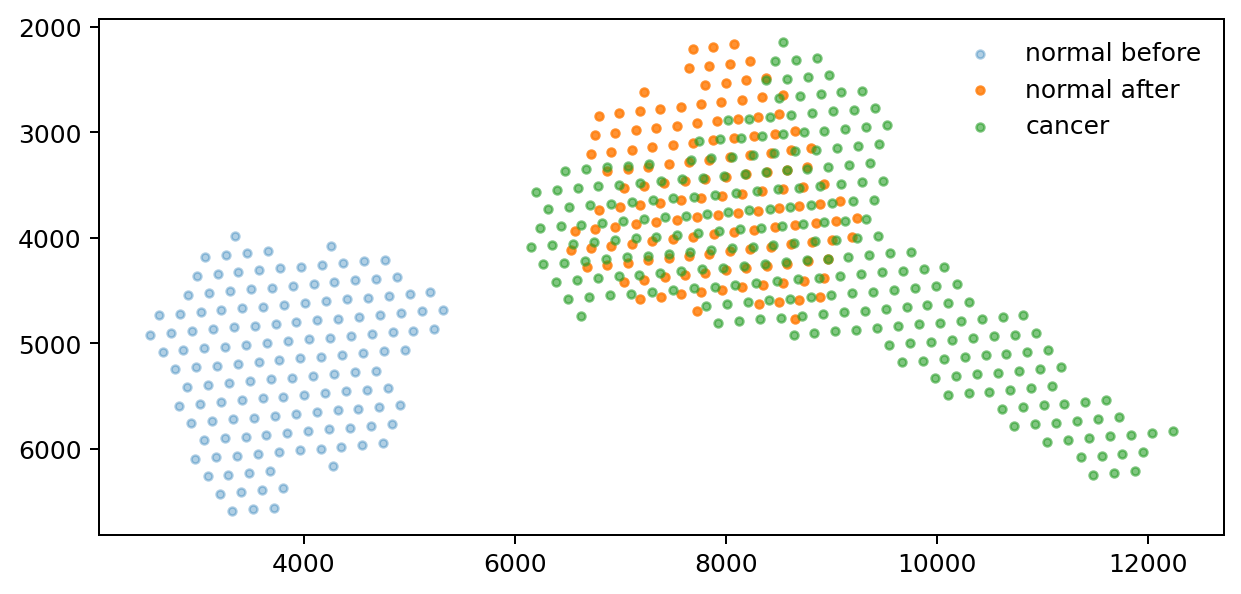

In [ ]:
plt.figure(figsize=(7, 7), dpi=180)
plt.scatter(X_base[mask_normal, 0], X_base[mask_normal, 1], s=10, alpha=0.35, label="normal before")
plt.scatter(X_after[mask_normal, 0], X_after[mask_normal, 1], s=10, alpha=0.85, label="normal after")
if mask_cancer.sum() > 0:
    plt.scatter(X_after[mask_cancer, 0], X_after[mask_cancer, 1], s=10, alpha=0.6, label="cancer")
plt.gca().set_aspect("equal")
plt.gca().invert_yaxis()
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

In [ ]:
adata_lower_clean

AnnData object with n_obs × n_vars = 408 × 36601
    obs: 'in_tissue', 'array_row', 'array_col', 'cluster', '_scvi_batch', '_scvi_labels', 'state', 'tissue_side', 'status', 'source', 'pos', 'cx_aligned', 'cy_aligned', 'cx_aligned_norm', 'cy_aligned_norm', 'cx_rigid_aligned', 'cy_rigid_aligned'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'cluster_colors'
    obsm: 'spatial', 'X_pca', 'X_umap', 'X_scanVI', 'spatial_aligned_init', 'spatial_aligned_init_norm', 'spatial_after_normal_to_cancer'
    varm: 'PCs'
    layers: 'counts'

In [ ]:
rng = np.random.default_rng(2025)
obs = adata_lower_clean.obs
keep_idx = []

for st, n_target in {"cancer": 246, "normal": 145}.items():
    idx = obs.index[obs["status"] == st].to_numpy()
    keep_idx.extend(rng.choice(idx, size=n_target, replace=False).tolist())

adata_lower_ds = adata_lower_clean[keep_idx].copy()
adata_lower_ds

AnnData object with n_obs × n_vars = 391 × 36601
    obs: 'in_tissue', 'array_row', 'array_col', 'cluster', '_scvi_batch', '_scvi_labels', 'state', 'tissue_side', 'status', 'source', 'pos', 'cx_aligned', 'cy_aligned', 'cx_aligned_norm', 'cy_aligned_norm', 'cx_rigid_aligned', 'cy_rigid_aligned'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'cluster_colors'
    obsm: 'spatial', 'X_pca', 'X_umap', 'X_scanVI', 'spatial_aligned_init', 'spatial_aligned_init_norm', 'spatial_after_normal_to_cancer'
    varm: 'PCs'
    layers: 'counts'

In [ ]:
adata_lower_ds


AnnData object with n_obs × n_vars = 391 × 36601
    obs: 'in_tissue', 'array_row', 'array_col', 'cluster', '_scvi_batch', '_scvi_labels', 'state', 'tissue_side', 'status', 'source', 'pos', 'cx_aligned', 'cy_aligned', 'cx_aligned_norm', 'cy_aligned_norm', 'cx_rigid_aligned', 'cy_rigid_aligned'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'cluster_colors'
    obsm: 'spatial', 'X_pca', 'X_umap', 'X_scanVI', 'spatial_aligned_init', 'spatial_aligned_init_norm', 'spatial_after_normal_to_cancer'
    varm: 'PCs'
    layers: 'counts'

/tmp/ipykernel_2853434/3854331490.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_lower_ds, color=["cluster"], spot_size=150)


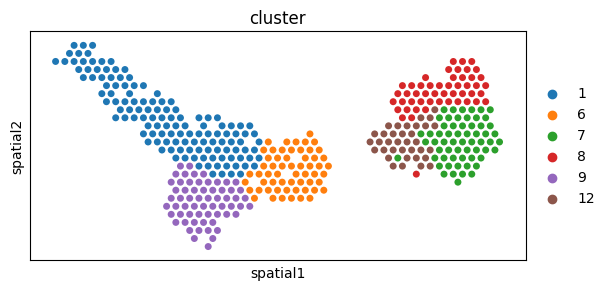

In [ ]:
sc.pl.spatial(adata_lower_ds, color=["cluster"], spot_size=150)